### 生成数据(传统方法)

In [1]:
import csv
import random
import math

# 用户输入
number = int(300)
money = float(60)
people = int(15)

# 检查人数是否过多
if people > money * 100:
    print("people is too many")
else:
    # 创建CSV文件
    with open('envelopes.csv', 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        
        # 写入表头
        header = ['Trial'] + [f'Person{p}' for p in range(1, people + 1)]
        writer.writerow(header)
        
        # 存储所有试验结果
        all_results = []
        
        # 执行number次试验
        for j in range(number):
            envelopes = []
            remaining_money = money
            
            for i in range(people):
                # 计算剩余人数
                remaining_people = people - i
                
                # 计算剩余钱的平均值
                avg_money = remaining_money / remaining_people
                
                # 计算最大可分配金额
                max_possible_avg = min(avg_money * 2, 
                                     remaining_money - (remaining_people - 1) * 0.01)
                min_amount = 0.01
                max_amount = max(max_possible_avg, min_amount)
                
                # 如果是最后一个人，给他所有剩余的钱
                if i == people - 1:
                    money_get = round(remaining_money, 2)
                else:
                    # 生成随机金额
                    money_get = random.uniform(min_amount, max_amount)
                    money_get = round(money_get, 2)
                
                envelopes.append(money_get)
                remaining_money -= money_get
                # 由于浮点数精度问题，确保remaining_money保持两位小数
                remaining_money = round(remaining_money, 2)
            
            # 写入当前试验结果
            row = [j + 1] + envelopes
            writer.writerow(row)
            all_results.append(envelopes)
        
        # 写入总计行（每个人的总金额）
        total_row = ['Total']
        for p in range(people):
            person_total = sum(all_results[j][p] for j in range(number))
            total_row.append(round(person_total, 2))
        writer.writerow(total_row)
        
    
    print("CSV文件已生成: envelopes.csv")

PermissionError: [Errno 13] Permission denied: 'envelopes.csv'

### 导入数据
计算mean,variance,std,median,min，max

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取CSV数据
path = "envelopes.csv"
raw = pd.read_csv(path)

# 2. 按行读取数据
data = raw.iloc[1:number].reset_index(drop=True)

# 3. 位次列
pos_cols = data.columns[1:people+1]

# 4. 转成长表
long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

# 提取位次编号
long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

# 5. 统计信息
stats = long_df.groupby("pos_id")["amount"].agg(
    mean="mean",
    variance="var",
    std="std",
    median="median",
    min="min",
    max="max"
)

print(stats)

            mean   variance       std  median   min    max
pos_id                                                    
1       3.838562   5.704389  2.388386    3.67  0.03   7.97
2       4.340635   5.398884  2.323550    4.51  0.06   8.39
3       4.133077   5.400130  2.323818    4.24  0.02   8.49
4       4.019699   5.172142  2.274234    4.16  0.02   8.89
5       4.020268   5.262880  2.294097    4.14  0.02   8.44
6       3.736990   5.548757  2.355580    3.63  0.03  10.25
7       3.947726   5.747502  2.397395    3.93  0.02   9.46
8       4.031940   5.817596  2.411969    3.93  0.03   9.92
9       3.889967   5.299929  2.302157    3.89  0.04  11.61
10      3.892609   6.189133  2.487797    3.89  0.03  10.33
11      4.105953   6.485352  2.546635    3.99  0.17  11.57
12      3.756020   6.472995  2.544208    3.50  0.01  15.25
13      4.169064   8.222351  2.867464    3.84  0.02  12.57
14      4.069632  10.612924  3.257748    3.45  0.02  17.07
15      4.047860   9.716687  3.117160    3.39  0.02  16.

Diffusion Model生成数据：

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取CSV数据
path = "generated_samples.csv"
raw = pd.read_csv(path)

# 2. 直接使用所有行，不需要额外的number参数
data = raw.copy()

# 3. 确定人数（列数）
people = data.shape[1]  # 列数代表人数
print(f"人数：{people}")

# 4. 为数据添加列名
pos_cols = [f"position_{i+1}" for i in range(people)]
data.columns = pos_cols

# 4. 转成长表
long_df = data[pos_cols].melt(
    var_name="position",
    value_name="amount"
).dropna()

# 提取位次编号
long_df["pos_id"] = long_df["position"].str.extract(r"(\d+)").astype(int) 

# 5. 统计信息
stats = long_df.groupby("pos_id")["amount"].agg(
    mean="mean",
    variance="var",
    std="std",
    median="median",
    min="min",
    max="max"
)

print(stats)

FileNotFoundError: [Errno 2] No such file or directory: 'generated_samples.csv'

#### 箱线图和散点图

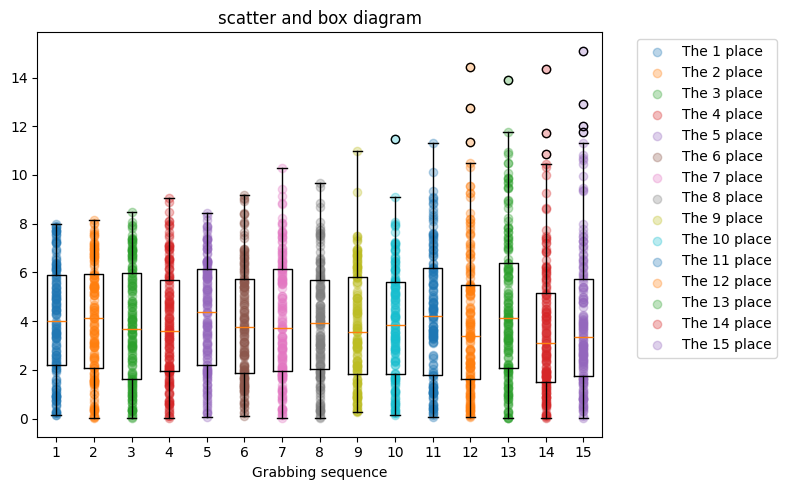

In [5]:
# 准备箱线图数据
box_data = [
    long_df[long_df["pos_id"] == pos]["amount"].values
    for pos in sorted(long_df["pos_id"].unique())
]
# 6. 散点图（不同位次不同颜色）
plt.figure(figsize=(8, 5))
plt.boxplot(box_data, showfliers=True)

for pos in sorted(long_df["pos_id"].unique()):
    y = long_df[long_df["pos_id"] == pos]["amount"]
    x = np.full(len(y), pos)
    plt.scatter(x, y, alpha=0.3, label=f"The {pos} place")

plt.xlabel("Grabbing sequence")
plt.ylabel("")
plt.title("scatter and box diagram")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

#### 画直方图（看分布形态）


蓝色为Diffusin Model生成数据的直方图，可以发现position_1不符合理论上的均匀分布，但当数据量足够大时，还是比较相似的。
这组数据 数据规模=10000，红包总额=100，人数=10

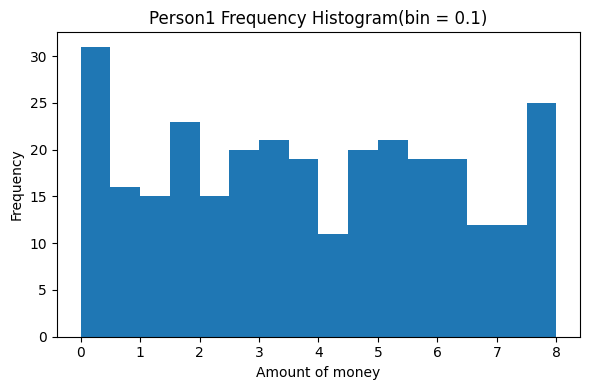

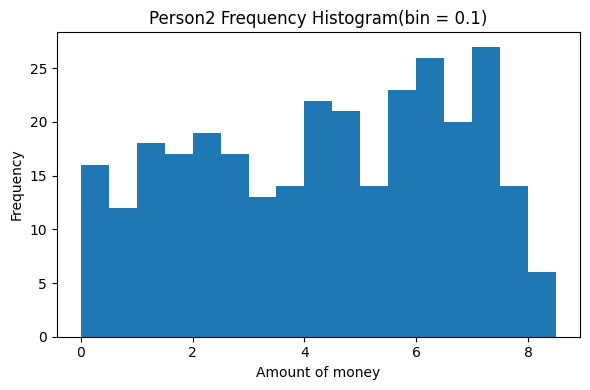

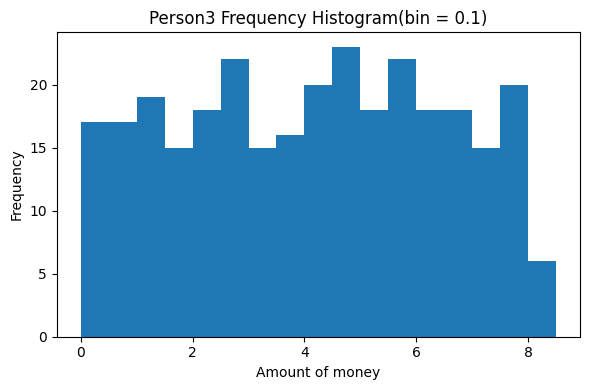

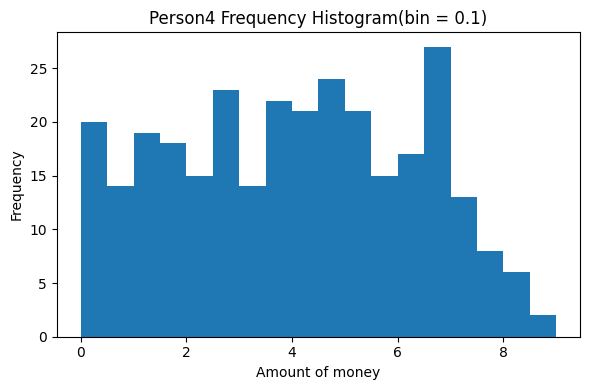

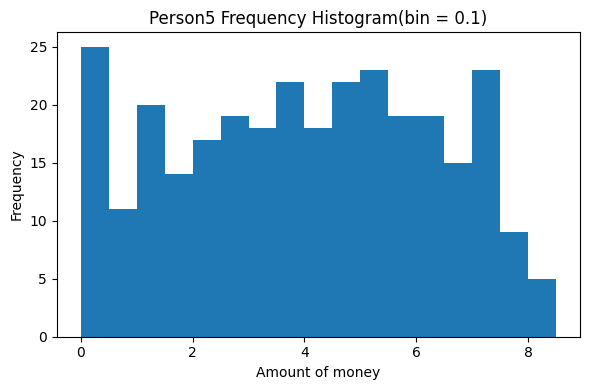

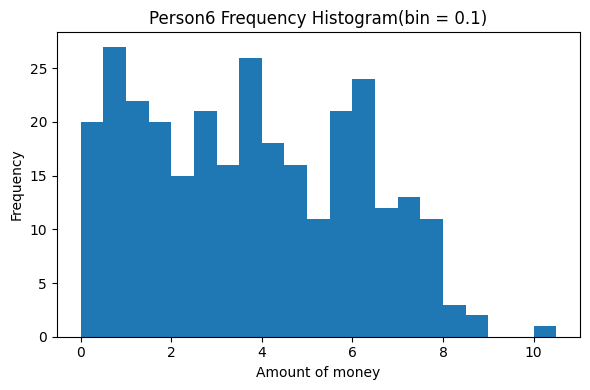

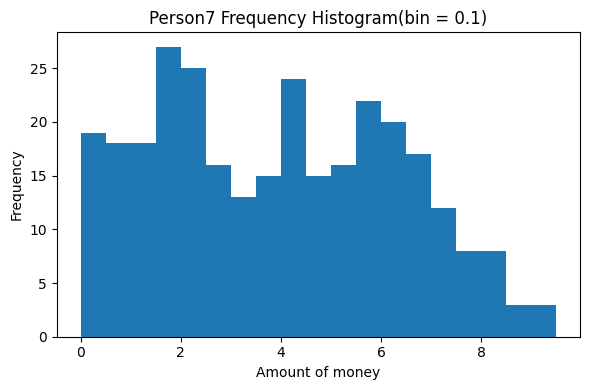

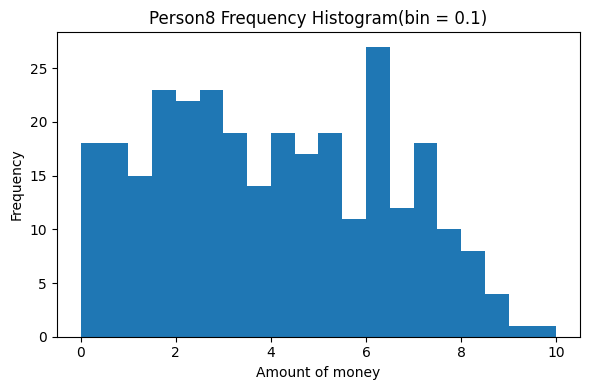

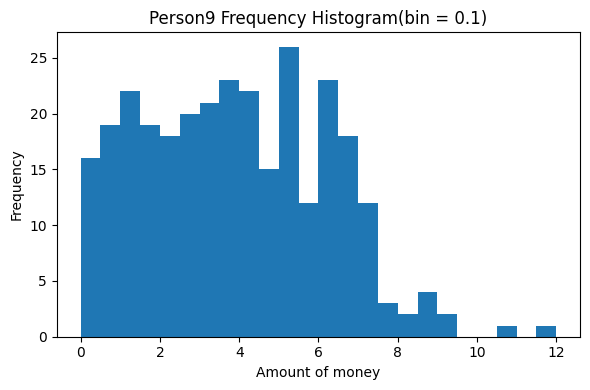

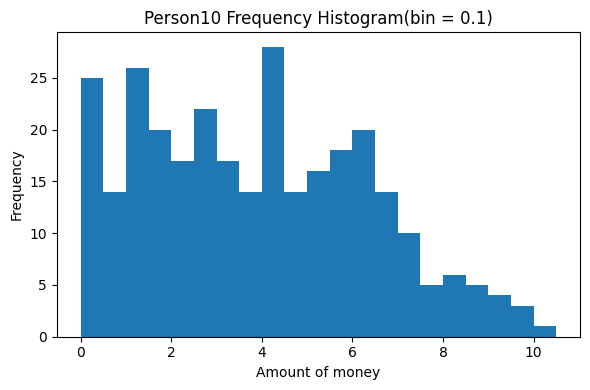

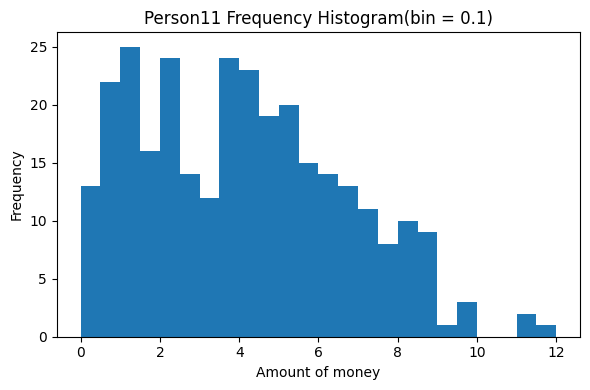

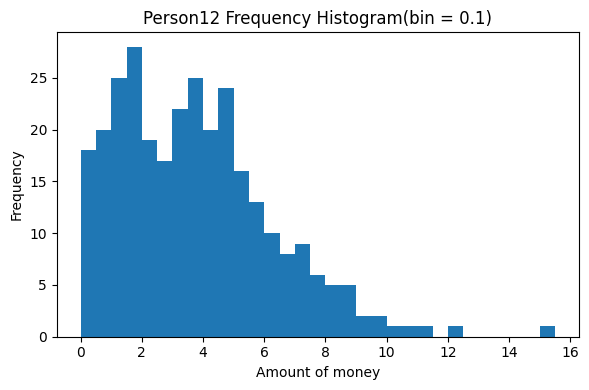

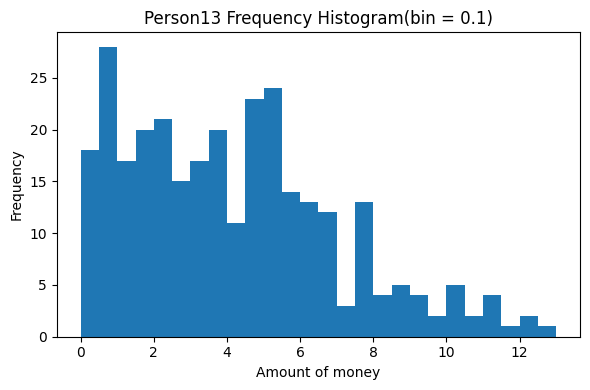

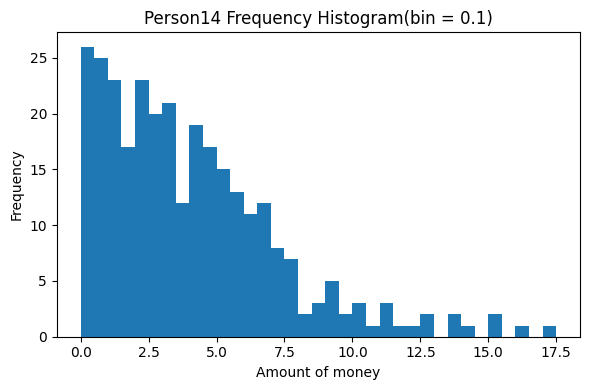

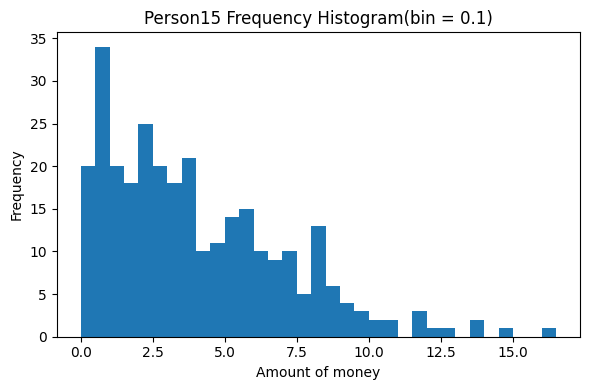

                bin_left  bin_right  count
position index                            
Person1  0           0.0        0.5     31
         1           0.5        1.0     16
         2           1.0        1.5     15
         3           1.5        2.0     23
         4           2.0        2.5     15


In [6]:
# 4. 直方图区间宽度
bin_width = 0.5

# 用于保存所有位次的频数统计结果
hist_tables = {}

for col in pos_cols:
    values = data[col].dropna().values
    
    # 构造 bins
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # 计算直方图频数
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # 绘制直方图
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins)
    plt.xlabel("Amount of money")
    plt.ylabel("Frequency")
    plt.title(f"{col} Frequency Histogram(bin = 0.1)")
    plt.tight_layout()
    plt.show()

# 5. 合并所有位次的频数统计（方便统一分析）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())

这是按照分布生成数据的直方图，可以与前面的直方图进行对比。最后几位的直方图已经显示出明显的长尾效应，看上去更像是指数分布，理论上也确实如此。

Person1


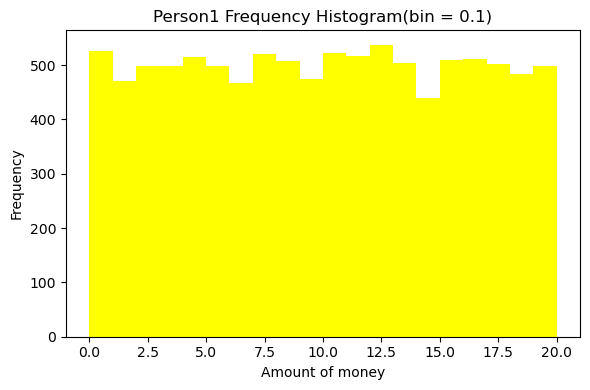

Person2


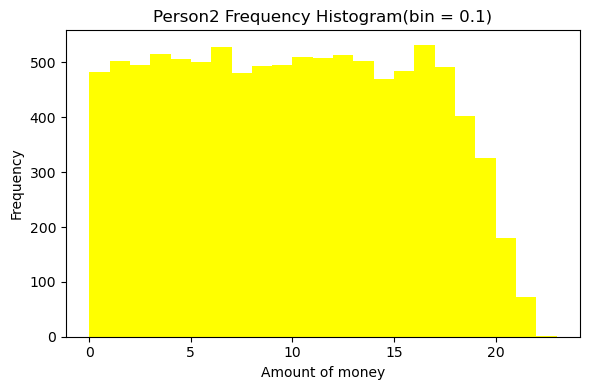

Person3


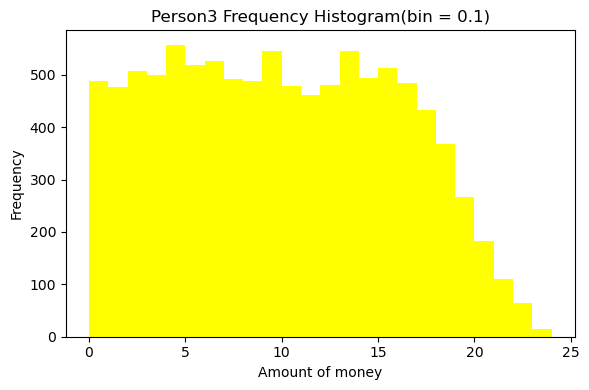

Person4


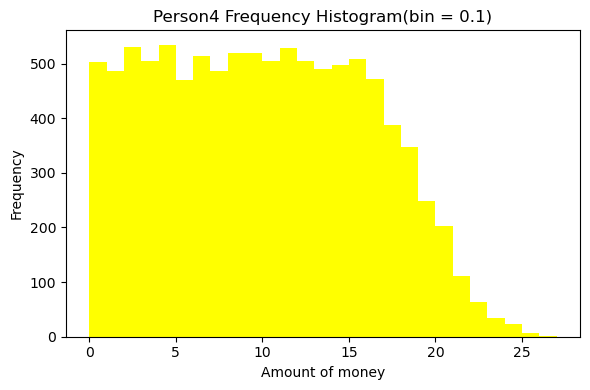

Person5


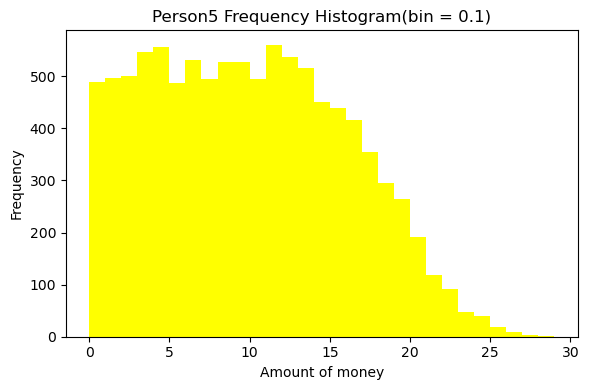

Person6


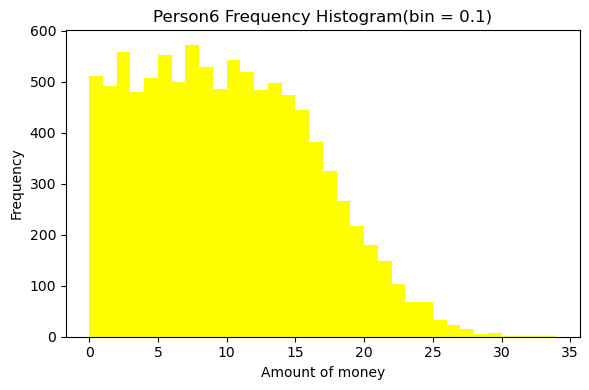

Person7


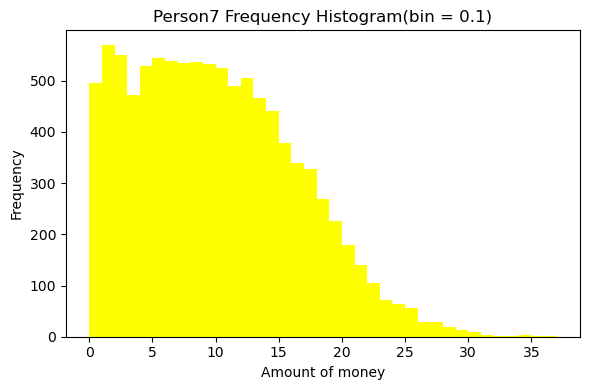

Person8


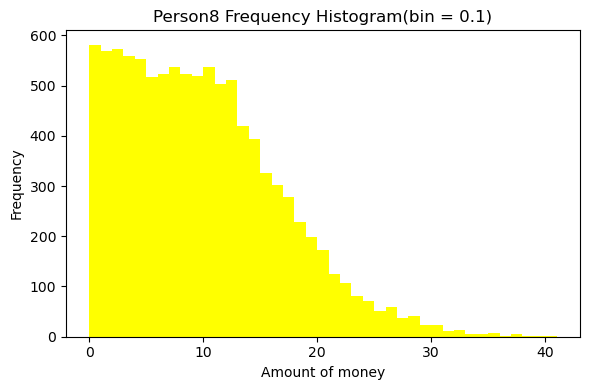

Person9


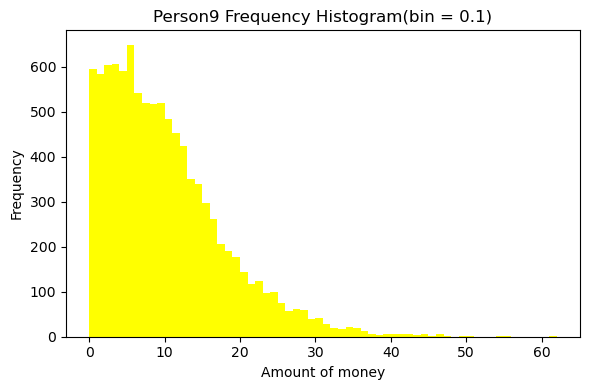

Person10


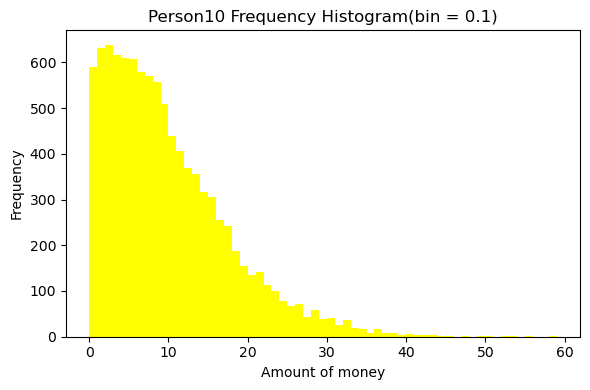

                bin_left  bin_right  count
position index                            
Person1  0           0.0        1.0    525
         1           1.0        2.0    471
         2           2.0        3.0    498
         3           3.0        4.0    499
         4           4.0        5.0    515


In [38]:
# 4. 直方图区间宽度
bin_width = 1

# 用于保存所有位次的频数统计结果
hist_tables = {}

for col in pos_cols:
    print(col)
    values = data[col].dropna().values
    
    # 构造 bins
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # 计算直方图频数
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # 绘制直方图
    plt.figure(figsize=(6, 4))
    plt.hist(values, bins=bins)
    plt.xlabel("Amount of money")
    plt.ylabel("Frequency")
    plt.title(f"{col} Frequency Histogram(bin = 0.1)")
    plt.hist(values, bins=bins, color='yellow')
    plt.tight_layout()
    plt.show()

# 5. 合并所有位次的频数统计（方便统一分析）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())

我们再来看看人数较多时的情况(P=1000)，并对最后几位的分布图与指数分布进行对照。

<>:59: SyntaxWarning: invalid escape sequence '\l'
<>:59: SyntaxWarning: invalid escape sequence '\l'
C:\Users\BlackWhite\AppData\Local\Temp\ipykernel_22868\1106813147.py:59: SyntaxWarning: invalid escape sequence '\l'
  label=f'Exp Dist ($\lambda$={lam:.4f})')


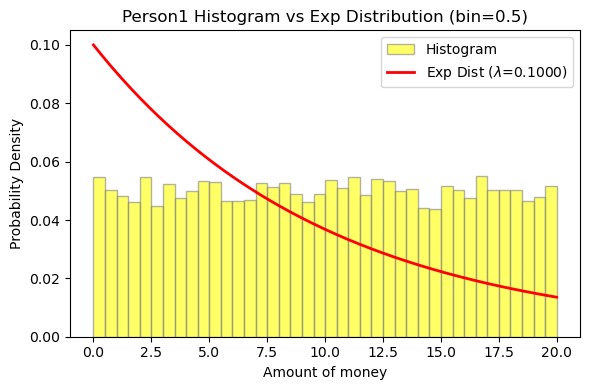

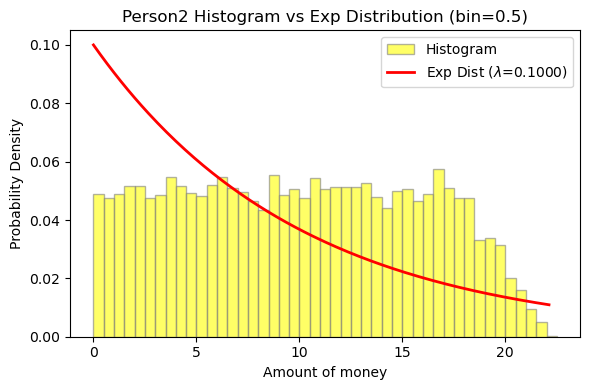

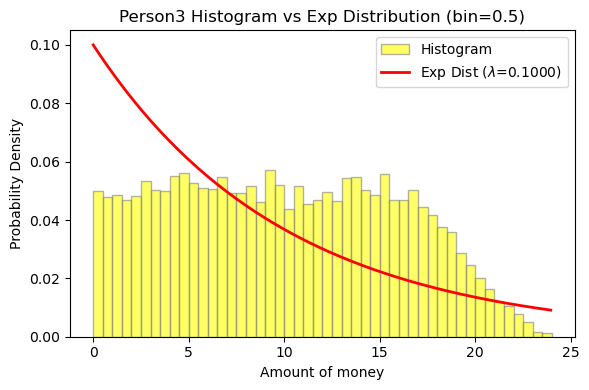

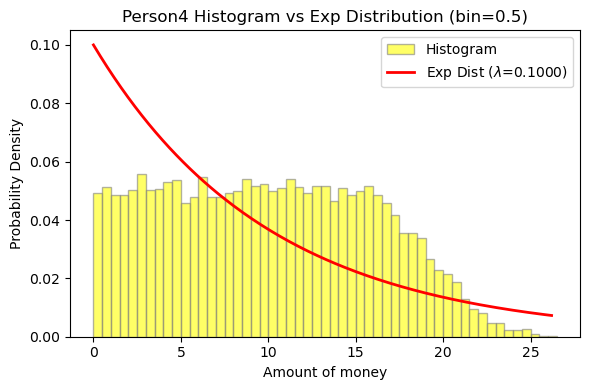

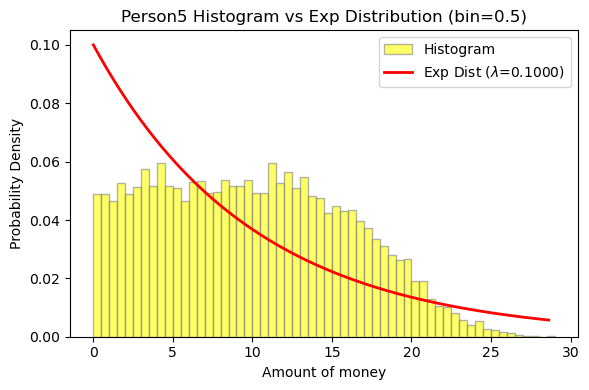

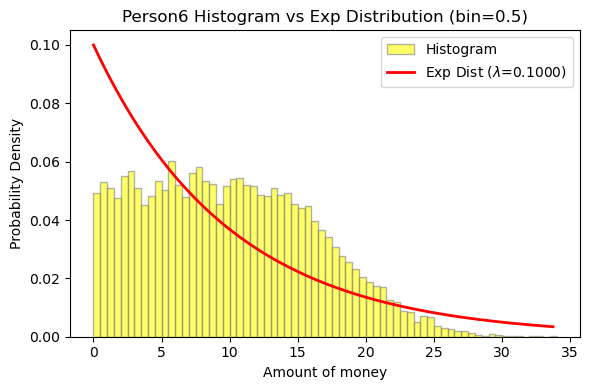

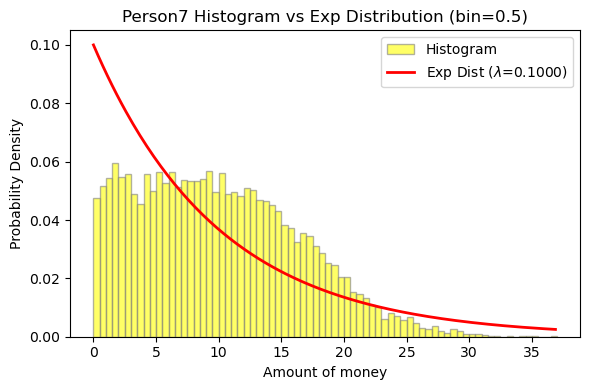

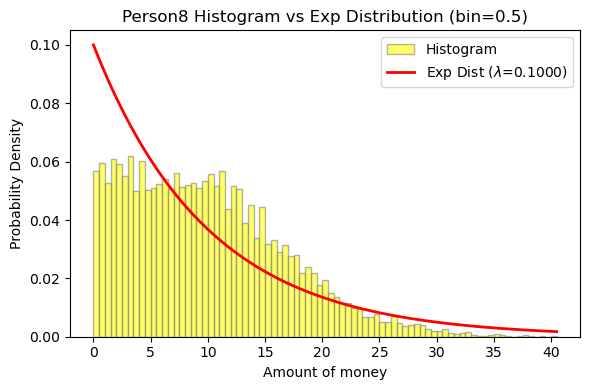

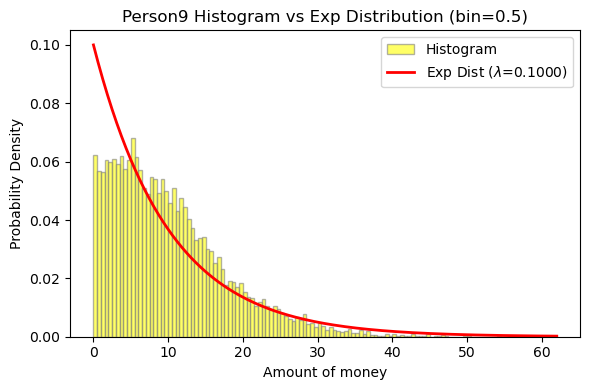

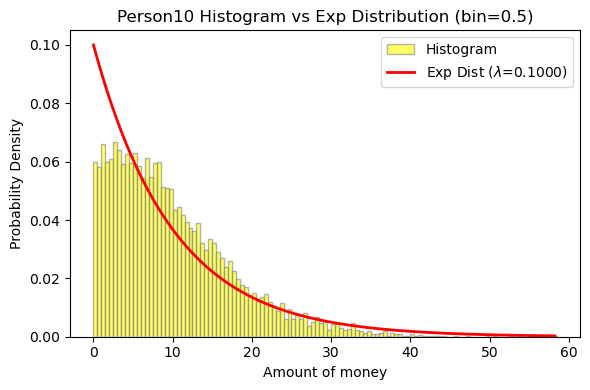

                bin_left  bin_right  count
position index                            
Person1  0           0.0        0.5    273
         1           0.5        1.0    252
         2           1.0        1.5    241
         3           1.5        2.0    230
         4           2.0        2.5    274


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 假设 bin_width 0.5
bin_width = 0.5

# 用于保存所有位次的频数统计结果
hist_tables = {}

# 使用 enumerate 获取索引 i，用于判断是否是第 10 列
for i, col in enumerate(pos_cols):
    values = data[col].dropna().values
    
    # 构造 bins
    if len(values) == 0: continue # 防止空数据报错
    max_val = values.max()
    bins = np.arange(0, max_val + bin_width, bin_width)
    
    # --- 1. 计算直方图频数 (用于保存表格，保持原有逻辑) ---
    counts, edges = np.histogram(values, bins=bins)
    
    # 记录频数表
    hist_df = pd.DataFrame({
        "bin_left": edges[:-1],
        "bin_right": edges[1:],
        "count": counts
    })
    hist_tables[col] = hist_df
    
    # --- 2. 绘制直方图与指数分布对比 (每10列取样一次) ---
    #if i % 10 == 0 and i >=900:
    if True:
        plt.figure(figsize=(6, 4))
        
        # A. 画直方图
        # 注意：这里必须设置 density=True，将频数转为概率密度，否则高度无法与概率曲线对比
        plt.hist(values, bins=bins, density=True, color='yellow', 
                 edgecolor='grey', alpha=0.6, label='Histogram')
        
        # B. 画指数分布概率密度函数 (PDF)
        # 估计 lambda 参数：指数分布的 lambda 通常估计为 1 / 均值
        # 如果你有固定的 lambda 值，可以直接赋值，例如: lam = 0.5
        lam = 0.1
        
        # 生成平滑的 x 轴坐标点
        x_curve = np.linspace(0, max_val, 200)
        # 计算对应的 y 值：f(x) = lambda * exp(-lambda * x)
        y_curve = lam * np.exp(-lam * x_curve)
        
        plt.plot(x_curve, y_curve, color='red', linewidth=2, 
                 label=f'Exp Dist ($\lambda$={lam:.4f})')
        
        # C. 图表设置
        plt.xlabel("Amount of money")
        plt.ylabel("Probability Density") # Y轴现在是密度，不再是简单的频数
        plt.title(f"{col} Histogram vs Exp Distribution (bin={bin_width})")
        plt.legend() # 显示图例
        plt.tight_layout()
        plt.show()

# 5. 合并所有位次的频数统计（保持不变）
all_hist_table = pd.concat(
    hist_tables,
    names=["position", "index"]
)

print(all_hist_table.head())

K-S检验验证第一个人抢到的金额是否是均匀分布。

In [44]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 提取第一个人的数据
first_place_data = data['Person1'].dropna().values
print(first_place_data)

# 2. 执行 K-S 检验
# args=(a, range) -> loc=a, scale=b-a
# 假设我们要检验数据是否服从 U(0, money/people)
statistic, p_value = stats.kstest(first_place_data, 'uniform', args=(0, 2*money/people))

print(f"K-S 统计量: {statistic:.4f}")
print(f"P值: {p_value:.4f}")

# 3. 结果解读
alpha = 0.05
if p_value < alpha:
    print("拒绝原假设：数据不服从 Uniform(0, 2*m/n)")
else:
    print("接受原假设：数据可能服从 Uniform(0, 2*m/n)")

[11.61  8.03  9.2  ... 13.04  6.72 19.5 ]
K-S 统计量: 0.0070
P值: 0.7138
接受原假设：数据可能服从 Uniform(0, 2*m/n)


K-S检验验证最后一个人抢到的金额是否符合指数分布

对于指数分布，除了看 $P$ 值，Q-Q 图 是最专业的辅助工具。原理： 将样本的各个分位数与指数分布的理论分位数画在散点图上。判断标准： 如果数据服从指数分布，散点应该几乎在一条 45 度的斜线上。

[15.18  3.86  4.56 ...  6.9   3.32 11.27]
参数：0.0100,9.9191
K-S 统计量: 0.0878
P值: 0.0000
拒绝原假设：数据不服从指数分布


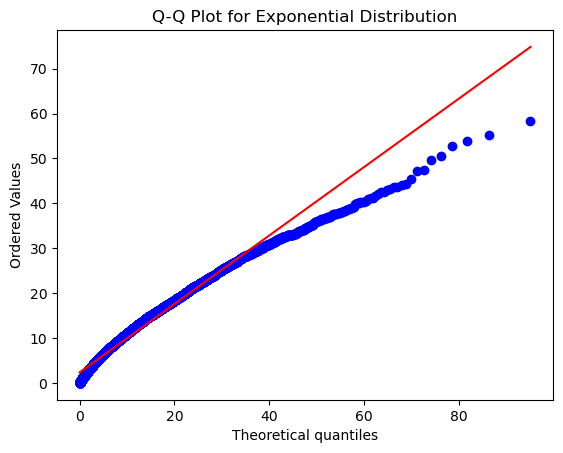

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# 提取最后一个人的数据
last_place_data = data['Person10'].dropna().values
print(last_place_data)

# 2. 执行 K-S 检验
# 检验数据是否服从指数分布
#loc_est, scale_est = 0, people/money

#通过数据估计参数
loc_est, scale_est = stats.expon.fit(last_place_data)

statistic, p_value = stats.kstest(last_place_data, 'expon', args=(loc_est, scale_est))

print(f"参数：{loc_est:.4f},{scale_est:.4f}")
print(f"K-S 统计量: {statistic:.4f}")
print(f"P值: {p_value:.4f}")

# 3. 结果解读
alpha = 0.05
if p_value < alpha:
    print("拒绝原假设：数据不服从指数分布")
else:
    print("接受原假设：数据可能服从指数分布")

stats.probplot(last_place_data, dist="expon", sparams=(loc_est, scale_est), plot=plt)
plt.title("Q-Q Plot for Exponential Distribution")
plt.show()